In [59]:
import torch
import timm
import torch.nn as nn

In [61]:
# Step 1: Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [63]:
# Step 2: Recreate the model architecture
model = timm.create_model('vit_base_patch16_224', pretrained=False)  # pretrained=False since we're loading custom weights
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)  # Replace NUM_CLASSES with the correct number (e.g. 4)
model = model.to(device)

In [69]:
# Step 3: Load the saved weights
model.load_state_dict(torch.load('saved_model/Vitbase_model.pth', map_location=device))

<All keys matched successfully>

In [71]:
# Step 4: Set the model to evaluation mode
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [75]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np

In [77]:
# Define transform (same as used in training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

In [81]:
# Load the test dataset
test_dataset = ImageFolder(root='D:/college/grad project/integrated/testing', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [83]:
# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [85]:
# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.90      0.93       400
meningioma_tumor       0.94      0.97      0.95       421
        no_tumor       0.97      1.00      0.98       510
 pituitary_tumor       0.97      0.97      0.97       374

        accuracy                           0.96      1705
       macro avg       0.96      0.96      0.96      1705
    weighted avg       0.96      0.96      0.96      1705



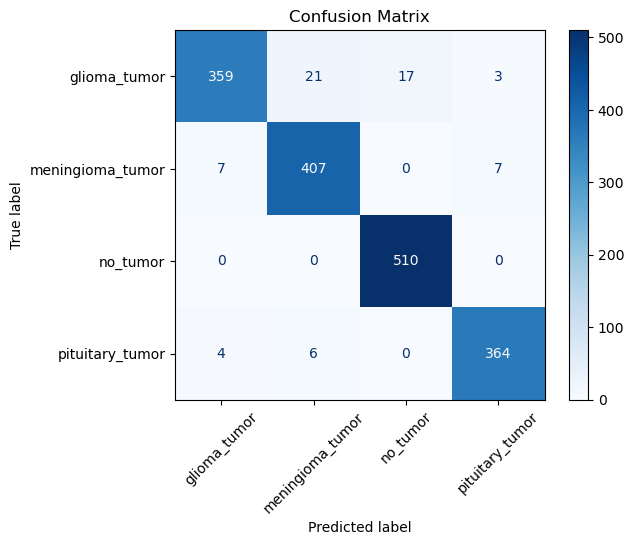

In [87]:
# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()